In [ ]:
import sys
sys.path.append("..")
sys.path.append("../api")

from api.AirbnbRemoteData import AirbnbRemoteData

berlin_listings_url = "https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/listings.csv"
munich_listing_url = "https://data.insideairbnb.com/germany/bv/munich/2025-09-27/visualisations/listings.csv"

airbnb_fetcher = AirbnbRemoteData(berlin_listings_url, munich_listing_url)
airbnb_fetcher.fetch_data()

In [ ]:
columns_df_a = airbnb_fetcher.get_berlin_data_frame_columns()
print(columns_df_a)

In [ ]:
columns_df_b = airbnb_fetcher.get_munich_data_frame_columns()
print(columns_df_b)

In [ ]:
merged_df = airbnb_fetcher.get_combined_data()
if merged_df is not None:
    print(f"Successfully merged!")
    display(merged_df.head(500))
else:
    print("Merge failed. Check if the CSVs share a common column name (like 'id' or 'listing_id').")

In [ ]:
merged_df['city'].value_counts()

In [ ]:
list(merged_df.columns)

In [ ]:
# the columns need to keep for analysis:price 

columns_to_keep = [
    'price',
    'room_type',
    'neighbourhood','city',
    'minimum_nights',
    'number_of_reviews','reviews_per_month','availability_365'
]
print(columns_to_keep)

In [ ]:
merged_df = merged_df[columns_to_keep]

merged_df

<Axes: ylabel='Frequency'>

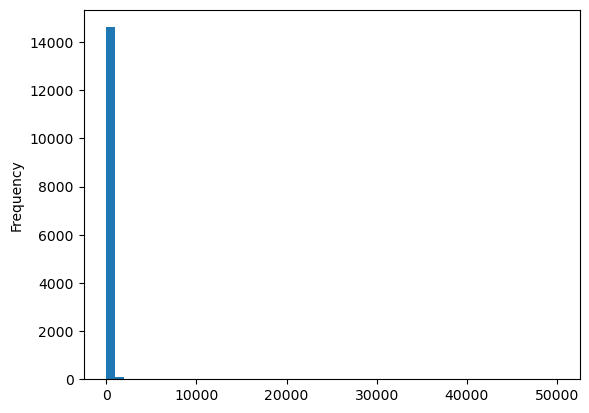

In [56]:
## Cleaning nas
df1=merged_df
df1.isnull().sum()
(df1.isnull().sum() / len(df1)) * 100
df2 = df1.dropna(subset=["price"]) # droping according to price
(df2.isnull().sum() / len(df2)) * 100

#df2.shape

## Dealing with duplicates ################
df2.duplicated().sum()
df3 = df2.drop_duplicates()
df3.duplicated().sum()

#df3.shape

## plotting price ###################
import matplotlib.pyplot as plt
df3["price"].plot(kind="hist", bins=50)
#df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50) 
#Message berlin_team_1

In [ ]:
df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50)

In [63]:
df3["revenue"] = df3["minimum_nights"]* df3["price"]
#df3['revenue'] = df3['minimum_nights'].astype(int) * df3['price'].astype(float)
df3["revenue"] = df3["revenue"].round(2)

C:\Users\bryan\AppData\Local\Temp\ipykernel_40812\2219169933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["revenue"] = df3["minimum_nights"]* df3["price"]
C:\Users\bryan\AppData\Local\Temp\ipykernel_40812\2219169933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["revenue"] = df3["revenue"].round(2)


In [66]:
df_berlin = df3[(df3['city'] == 'Berlin') & (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(
    ['neighbourhood', 'room_type'], as_index=False)['revenue'].sum()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Alexanderplatz,Entire home/apt,2008392.0
1,Brunnenstr. Süd,Entire home/apt,1147360.0
2,Frankfurter Allee Süd FK,Entire home/apt,1127724.0
3,Tempelhofer Vorstadt,Entire home/apt,912365.0
4,Prenzlauer Berg Südwest,Entire home/apt,771116.0
...,...,...,...
302,Otto-Suhr-Allee,Shared room,50.0
303,Kantstraße,Shared room,48.0
304,Neu-Hohenschönhausen Süd,Entire home/apt,45.0
305,Gropiusstadt,Private room,37.0


In [67]:
df_berlin = df3[(df3['city'] == 'Berlin') & (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False)
berlin_revenue = berlin_revenue.reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Westend,Hotel room,74520.00
1,Heerstraße Nord,Entire home/apt,6745.50
2,Schmargendorf,Entire home/apt,6637.45
3,Müggelheim,Private room,6440.00
4,Hellersdorf-Nord,Private room,6067.33
...,...,...,...
302,Gropiusstadt,Private room,37.00
303,Tempelhofer Vorstadt,Shared room,33.29
304,Reuterstraße,Shared room,31.00
305,Schöneberg-Nord,Shared room,30.25


In [74]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Entire home/apt') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Heerstraße Nord,Entire home/apt,6745.50
1,Schmargendorf,Entire home/apt,6637.45
2,Zehlendorf Südwest,Entire home/apt,5844.14
3,Zehlendorf Nord,Entire home/apt,5795.00
4,Grunewald,Entire home/apt,5690.20
...,...,...,...
131,Falkenhagener Feld,Entire home/apt,240.50
132,MV 2,Entire home/apt,198.00
133,Altstadt-Kietz,Entire home/apt,166.33
134,Allende-Viertel,Entire home/apt,50.00


In [77]:
df_munich = df3[
    (df3['city'] == 'Munich') & 
    (df3['room_type'] == 'Entire home/apt') &
    (df3['price'] < 1000)].copy()

munich_revenue = df_munich.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

munich_revenue = munich_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
munich_revenue["revenue"] = munich_revenue["revenue"].round(2)
munich_revenue

,neighbourhood,room_type,revenue
0,Altstadt-Lehel,Entire home/apt,1929.83
1,Hadern,Entire home/apt,1856.18
2,Au-Haidhausen,Entire home/apt,1519.79
3,Schwabing-West,Entire home/apt,1512.70
4,Pasing-Obermenzing,Entire home/apt,1507.75
5,Neuhausen-Nymphenburg,Entire home/apt,1402.23
6,Maxvorstadt,Entire home/apt,1367.87
7,Ludwigsvorstadt-Isarvorstadt,Entire home/apt,1249.89
8,Untergiesing-Harlaching,Entire home/apt,1240.63
9,Milbertshofen-Am Hart,Entire home/apt,1221.41


In [70]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Private room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Müggelheim,Private room,6440.00
1,Hellersdorf-Nord,Private room,6067.33
2,Wilhelmstadt,Private room,5194.00
3,Lankwitz,Private room,4305.00
4,Schmargendorf,Private room,4283.00
...,...,...,...
127,West 1,Private room,71.00
128,Zehlendorf Südwest,Private room,62.00
129,Weißensee Ost,Private room,53.00
130,Altglienicke,Private room,49.50


In [71]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Shared room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Adlershof,Shared room,4140.00
1,nördliche Luisenstadt,Shared room,396.00
2,Moabit West,Shared room,363.67
3,Moabit Ost,Shared room,106.50
4,Niederschöneweide,Shared room,66.00
5,südliche Luisenstadt,Shared room,62.67
6,Blankenfelde/Niederschönhausen,Shared room,59.00
7,Karl-Marx-Allee-Süd,Shared room,55.82
8,Prenzlauer Berg Südwest,Shared room,55.25
9,Parkviertel,Shared room,55.00


In [72]:
df_berlin = df3[
    (df3['city'] == 'Berlin') & 
    (df3['room_type'] == 'Hotel room') &
    (df3['price'] < 1000)].copy()

berlin_revenue = df_berlin.groupby(['neighbourhood', 'room_type'], as_index=False)['revenue'].mean()

berlin_revenue = berlin_revenue.sort_values(by='revenue', ascending=False).reset_index(drop=True)
berlin_revenue["revenue"] = berlin_revenue["revenue"].round(2)
berlin_revenue

,neighbourhood,room_type,revenue
0,Westend,Hotel room,74520.00
1,Karlshorst,Hotel room,1191.00
2,Prenzlauer Berg Ost,Hotel room,1097.00
3,Otto-Suhr-Allee,Hotel room,980.80
4,Wilhelmstadt,Hotel room,528.00
5,Prenzlauer Berg Südwest,Hotel room,421.17
6,Spandau Mitte,Hotel room,388.33
7,Frankfurter Allee Nord,Hotel room,334.00
8,Tiergarten Süd,Hotel room,264.50
9,Halensee,Hotel room,260.25


In [69]:
df3['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'],
      dtype=object)